#Rafael Giordano Fuentes Bonnett
exercicio feito individualmente

Para abrir o notebook no Google Colab, altere o domínio `github.com` para `githubtocolab.com`

<div class="alert alert-block alert-danger">
Para praticar programação, é importante que você erre, leia as mensagens de erro e tente corrigí-los.
    
Dessa forma, no Google Colab, é importante que você DESATIVE OS RECURSOS DE AUTOCOMPLETAR:

- Menu Ferramentas -> Configurações
- Na janela que é aberta:
  - Seção Editor -> Desativar "Mostrar sugestões de preenchimento de código com base no contexto"
  - Seção Assistência de IA -> Desabilitar itens

Na versão em inglês:

- Menu Tools -> Settings
- Na janela que é aberta:
  - Seção Editor -> Desativar "Show context-powered code completions"
  - Seção AI Assistance -> Desabilitar itens
</div>

# Exercício 4 - CNN

Neste exercício, você vai trabalhar com o banco de dados [Fashion MNIST](https://arxiv.org/abs/1708.07747) e implementar um classificador multiclasse usando uma CNN. Esse dataset contem 70000 imagens 28x28 de peças de vestuário distribuídas em 10 classes, divididas em um conjunto de treinamento com 60000 imagens e um de teste com 10000.

O banco de dados Fashion MNIST tem as mesmas características do banco de dados MNIST (imagens 28x28 e 10 classes), sendo possível substituí-lo diretamente. A sugestão é que seja usado o exemplo da [CNN com PyTorch](ap_exemplo_pytorch_cnn.ipynb), substituindo a parte de carregamento de dados do MNIST, para o Fashion MNIST, como no exemplo:

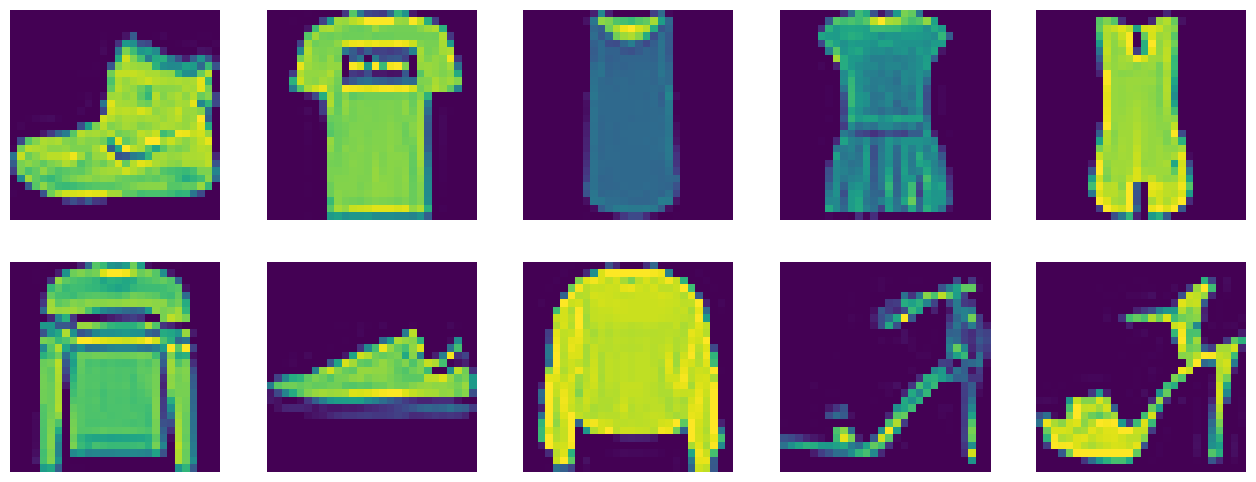

In [12]:
import matplotlib.pyplot as plt
import torch

from torchvision import datasets, transforms

Nb = 64

dir_data = "~/temp"

train_loader = torch.utils.data.DataLoader(
    datasets.FashionMNIST(
        dir_data,
        train=True,
        download=True,
        transform=transforms.Compose(
            [transforms.ToTensor()]
        ),
    ),
    batch_size=Nb,
    shuffle=True,
)

plt.figure(figsize=(16, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    image, _ = train_loader.dataset.__getitem__(i)
    plt.imshow(image.squeeze().numpy())
    plt.axis('off');

Você deve implementar uma rede CNN, com a etapa de treinamento e teste, de forma que o resultado de acurácia da classificação seja **superior à 90%** considerando os dados de teste. Para tanto, faça simulações alterando a arquitetura da rede ou ajustando os hiperparâmetros, até conseguir o desempenho desejado.

Ao final do exercício, você deverá apresentar:

1. Os códigos utilizados para treinar o modelo e avaliá-lo com os conjuntos de teste;

2. O valor obtido para a acurácia considerando os dados de teste.

A sugestão é que o relatório seja elaborado utilizando um Jupyter Notebook e a linguagem Python, já que essas são as ferramentas que estamos utilizando neste bloco do curso. No entanto, isso não é obrigatório e você pode usar outra linguagem de programação, caso queira.

## Instruções para entrega

- O exercício pode ser feito em dupla ou individualmente;

- A entrega deve incluir:
  - Um vídeo de no **máximo 40s**, mostrando a resolução do exercício;
  - Os **códigos-fontes** dos programas, preferencialmente organizados em um Jupyter Notebook, descrevendo o experimento e mostrando como foram obtidos os resultados solicitados.

- **A correção será feita baseada no vídeo**. Quando o professor/pesquisador ficar com alguma dúvida, serão consultados os códigos-fonte;

- Sobre o vídeo:
  - **Deve incluir áudio** descrevendo o experimento;
  - Gravem a tela do computador usando celular ou usando algum programa de captura de tela (por exemplo Zoom, Google Meet, ou OBS Studio);
  - No início, **deve aparecer o rosto e algum documento do aluno que gravou o vídeo** (como a carteira USP, RG, CNH, etc);
  - No caso de entrega em dupla, **não é necessário que os dois componentes apareçam no vídeo**. No entanto, alternem o apresentador ao longo das entregas dos exercícios e **não esqueçam de incluir os dois nomes no início do vídeo**.
  - Procurem convencer o espectador do vídeo, que vai corrigir o exercício que fizeram os exercícios computacionais solicitados e que eles estão funcionando corretamente. Tentem fazer um bom aproveitamento do tempo para apresentar os resultados solicitados, **respeitando o limite de 40s e não acelerem a velocidade do vídeo**;

- Sobre os códigos-fonte:
  - **Incluir o nome do(s) aluno(s)** no início do programa;

- Sobre o envio no Moodle:
  - Apenas um aluno de cada dupla deve enviar o vídeo no Moodle;
  - Podem ser enviados o arquivo de vídeo (.mkv, .mp4, .avi, etc.) ou um link para o vídeo (Youtube, Google Drive, etc);
    - No segundo caso, certifiquem-se que todos os professores/pesquisadores (magno.silva@usp.br, hae.kim@usp.br, sergiocaceres01@usp.br, renatocan@lps.usp.br) tenham acesso ao seu vídeo.
  - Não se esqueçam de escrever o nome dos componentes da dupla (ou do único aluno, escrevendo: "exercício feito individualmente") em três lugares diferentes: **no campo "comentários sobre o envio" no Moodle**, **no início do vídeo** e no **início dos códigos-fonte**.



#Desarrollo

In [13]:
import numpy
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torchvision import datasets, transforms

# Ajuste de hiperparâmetros

# passo de adaptação (reduzido para maior estabilidade com Adam)
eta = 0.001

# Tamanho do mini-batch
Nb = 64

# Tamanho do mini-batch usado no teste
Nb_test = 1000

# Número de épocas (aumentado para garantir acurácia > 90%)
Ne = 15

carga de datos

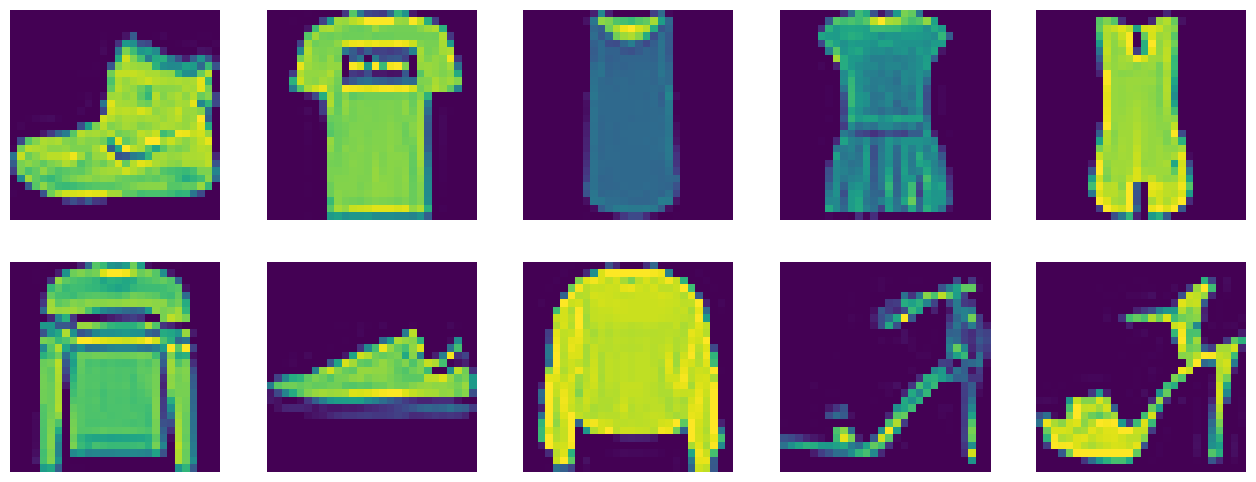

In [14]:
dir_data = "~/temp"

train_loader = torch.utils.data.DataLoader(
    datasets.FashionMNIST(
        dir_data,
        train=True,
        download=True,
        transform=transforms.Compose(
            [transforms.ToTensor()]
        ),
    ),
    batch_size=Nb,
    shuffle=True,
)

test_loader = torch.utils.data.DataLoader(
    datasets.FashionMNIST(
        dir_data,
        train=False,
        transform=transforms.Compose(
            [transforms.ToTensor()]
        ),
    ),
    batch_size=Nb_test,
    shuffle=True,
)

plt.figure(figsize=(16, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    image, _ = train_loader.dataset.__getitem__(i)
    plt.imshow(image.squeeze().numpy())
    plt.axis('off')

modelo de ML

In [15]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        # Camada convolucional 1
        # Entra 1 canal, saem 32.
        # Mantendo kernel 5x5 e padding 2 para manter a dimensionalidade 28x28 antes do pooling.
        self.conv1=nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=5,
                stride=1,
                padding=2,
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        # Camada convolucional 2
        # Entrada 32 canais, saída 64.
        self.conv2=nn.Sequential(
            nn.Conv2d(32,64,5,1,2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Camadas totalmente conectadas
        # A imagem de 28x28 foi reduzida pela metade duas vezes (28 -> 14 -> 7)
        # Ficamos com tensores 64 x 7 x 7
        self.fc1=nn.Linear(64*7*7,128)
        self.relu=nn.ReLU()
        self.out=nn.Linear(128,10)

    def forward(self,x):
        x=self.conv1(x)
        x=self.conv2(x)

        x=x.view(x.size(0),-1)

        x=self.fc1(x)
        x=self.relu(x)
        output=self.out(x)
        return output

In [16]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Instanciando modelo
model = Model().to(device)

# Função custo para treinamento
loss_function = nn.CrossEntropyLoss()

# Otimizador
optimizer = torch.optim.Adam(model.parameters(), lr = eta)

entrenamiento

Época: 0 [0/60000 (0%)]	Loss: 2.307876
Época: 0 [19200/60000 (32%)]	Loss: 0.505641
Época: 0 [38400/60000 (64%)]	Loss: 0.361378
Época: 0 [57600/60000 (96%)]	Loss: 0.396430
Época: 1 [0/60000 (0%)]	Loss: 0.267584
Época: 1 [19200/60000 (32%)]	Loss: 0.370097
Época: 1 [38400/60000 (64%)]	Loss: 0.252664
Época: 1 [57600/60000 (96%)]	Loss: 0.202670
Época: 2 [0/60000 (0%)]	Loss: 0.175021
Época: 2 [19200/60000 (32%)]	Loss: 0.299540
Época: 2 [38400/60000 (64%)]	Loss: 0.196941
Época: 2 [57600/60000 (96%)]	Loss: 0.234355
Época: 3 [0/60000 (0%)]	Loss: 0.258570
Época: 3 [19200/60000 (32%)]	Loss: 0.145557
Época: 3 [38400/60000 (64%)]	Loss: 0.194761
Época: 3 [57600/60000 (96%)]	Loss: 0.117934
Época: 4 [0/60000 (0%)]	Loss: 0.293831
Época: 4 [19200/60000 (32%)]	Loss: 0.145964
Época: 4 [38400/60000 (64%)]	Loss: 0.200130
Época: 4 [57600/60000 (96%)]	Loss: 0.290523
Época: 5 [0/60000 (0%)]	Loss: 0.161530
Época: 5 [19200/60000 (32%)]	Loss: 0.069603
Época: 5 [38400/60000 (64%)]	Loss: 0.248664
Época: 5 [57600/60

Text(0.5, 1.0, 'Evolução da Função Custo')

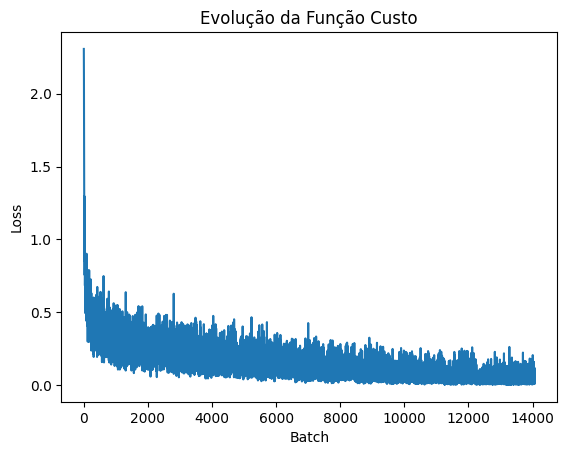

In [17]:
# Lista usada para guardar o valor da função custo ao longo das iterações
losses=[]

# Loop das épocas
for epoch in range(Ne):
    # Loop dos mini batches
    for n,(X,d) in enumerate(train_loader):
        # Envia os dados para a GPU, caso ela exista
        X=X.to(device=device)
        d=d.to(device=device)

        X=X.view(-1,1,28,28)

        model.train()
        model.zero_grad()
        y=model(X)
        loss=loss_function(y,d)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        # Mostra o valor da função custo a cada 300 iterações para não poluir tanto a tela
        if n%300==0:
            N_all=len(train_loader.dataset)
            n_ex=n*len(X)
            p=100.*n/len(train_loader)
            print(
                f"Época: {epoch} [{n_ex}/{N_all} ({p:.0f}%)]\tLoss: {loss:.6f}"
            )

plt.figure()
plt.plot(losses)
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Evolução da Função Custo")

test em conjunto de pruebas

In [20]:
# Variável usada para contabilizar o número de acertos
correct=0

# Loop dos mini batches
for n,(X,d) in enumerate(test_loader):
    X=X.to(device=device)
    d=d.to(device=device)

    X=X.view(-1,1,28,28)

    model.eval()

    # Desativa o cálculo de gradientes para economizar memória e tempo no teste
    with torch.no_grad():
        y=model(X)

        pred=torch.max(y,1,keepdim=True)[1]
        correct+=pred.eq(d.view_as(pred)).cpu().sum().item()

# Mostra o desempenho obtido no teste
accuracy=100.*correct/len(test_loader.dataset)
print(f"Acurácia: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)")

Acurácia: 9160/10000 (91.60%)
